### Importación de datos



In [18]:
# @title
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

lista_tiendas = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

tienda.head(3)


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444


#1. Análisis de facturación



In [19]:
# @title

print("Facturación neta (en millones)")
facturacion_neta = []

for df in lista_tiendas:
    # Calculamos la ganancia neta de cada transacción y luego la sumamos
    neta = (df['Precio'] - df['Costo de envío']).sum()
    facturacion_neta.append(neta)

tabla_facturacion = pd.DataFrame({
    'Tienda': nombres_tiendas,
    'Facturación Neta': facturacion_neta
})

# Ordenamos por rentabilidad
tabla_facturacion = tabla_facturacion.sort_values(by='Facturación Neta', ascending=False)

# Aplicamos el formato de Millones (M) con 2 decimales
tabla_facturacion['Facturación Neta'] = tabla_facturacion['Facturación Neta'].apply(lambda x: f"{x/1_000_000:.2f} M")

display(tabla_facturacion)

Facturación neta (en millones)


,Tienda,Facturación Neta
0,Tienda 1,1089.50 M
1,Tienda 2,1056.86 M
2,Tienda 3,1039.50 M
3,Tienda 4,983.06 M


In [20]:
# @title
# Comparación de volumen total de órdenes
print("VOLUMEN TOTAL DE OPERACIONES")
for i, df in enumerate(lista_tiendas):
    total_ordenes = len(df)
    ingresos_totales = df['Precio'].sum()
    print(f"{nombres_tiendas[i]}: {total_ordenes:,} órdenes | Total: ${ingresos_totales:,.2f}")

VOLUMEN TOTAL DE OPERACIONES
Tienda 1: 2,359 órdenes | Total: $1,150,880,400.00
Tienda 2: 2,359 órdenes | Total: $1,116,343,500.00
Tienda 3: 2,359 órdenes | Total: $1,098,019,600.00
Tienda 4: 2,358 órdenes | Total: $1,038,375,700.00


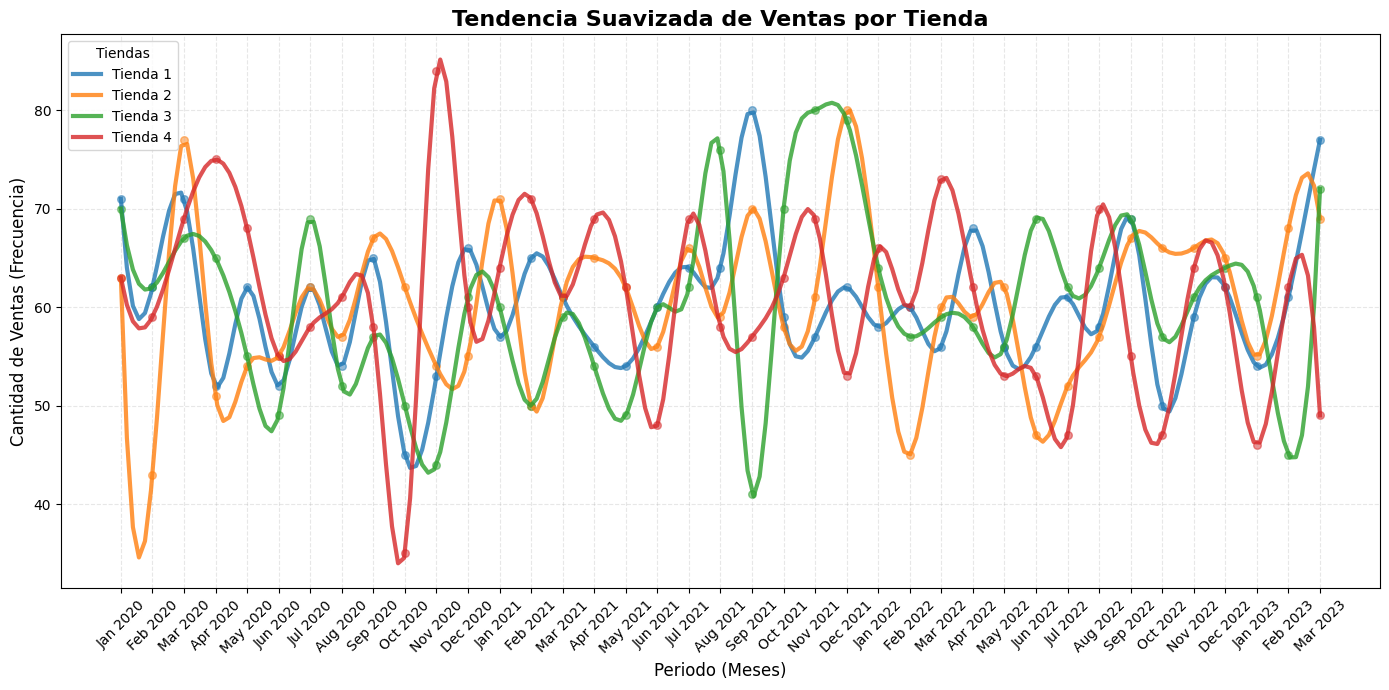

In [21]:
# @title
from scipy.interpolate import make_interp_spline

# Configuración del gráfico
plt.figure(figsize=(14, 7))

for i, df in enumerate(lista_tiendas):
    # Aseguramos que la fecha sea datetime
    df['Fecha de Compra'] = pd.to_datetime(df['Fecha de Compra'], dayfirst=True)

    # Agrupamos por mes para ver la frecuencia
    ventas_mensuales = df.resample('MS', on='Fecha de Compra')['Producto'].count()

    # Proceso de suavizado
    # Convertimos las fechas a números para poder calcular la curva
    x = np.arange(len(ventas_mensuales))
    y = ventas_mensuales.values

    # Creamos más puntos entre los meses para que la curva sea fluida
    x_smooth = np.linspace(x.min(), x.max(), 200)
    spl = make_interp_spline(x, y, k=3) # k=3 para curva cúbica (suave)
    y_smooth = spl(x_smooth)

    # Graficamos la línea suavizada
    plt.plot(x_smooth, y_smooth, linewidth=3, label=nombres_tiendas[i], alpha=0.8)

    # Dibujamos los puntos originales sutilmente para no perder precisión
    plt.scatter(x, y, s=30, alpha=0.5)

# Personalización estética
plt.title('Tendencia Suavizada de Ventas por Tienda', fontsize=16, fontweight='bold')
plt.xlabel('Periodo (Meses)', fontsize=12)
plt.ylabel('Cantidad de Ventas (Frecuencia)', fontsize=12)

# Ajustamos las etiquetas del eje X para que coincidan con los meses reales
plt.xticks(range(len(ventas_mensuales)),
           [d.strftime('%b %Y') for d in ventas_mensuales.index],
           rotation=45)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title="Tiendas", loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

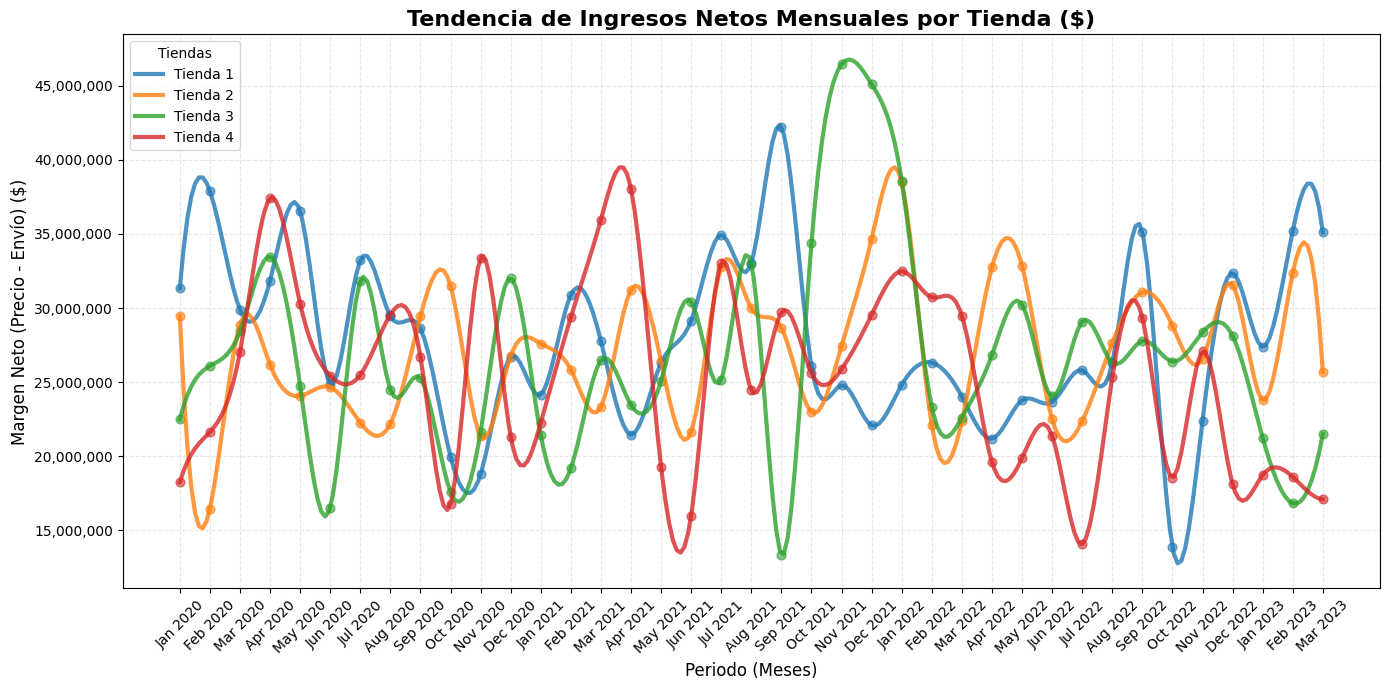

In [22]:
# @title
from scipy.interpolate import make_interp_spline

# Configuración del gráfico
plt.figure(figsize=(14, 7))

for i, df in enumerate(lista_tiendas):
    # Aseguramos que la fecha sea datetime
    df['Fecha de Compra'] = pd.to_datetime(df['Fecha de Compra'], dayfirst=True)

    # Cálculo de ingreso neto
    # Creamos una columna temporal para el cálculo
    df['Ingreso_Neto'] = df['Precio'] - df['Costo de envío']

    # Agrupamos por mes y sumamos los ingresos netos
    ingresos_mensuales = df.resample('MS', on='Fecha de Compra')['Ingreso_Neto'].sum()

    # Proceso de suavizado
    x = np.arange(len(ingresos_mensuales))
    y = ingresos_mensuales.values

    # Generamos puntos intermedios para la curva
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spl = make_interp_spline(x, y, k=3)
    y_smooth = spl(x_smooth)

    # Graficamos la línea de ingresos netos
    plt.plot(x_smooth, y_smooth, linewidth=3, label=nombres_tiendas[i], alpha=0.8)

    # Puntos reales
    plt.scatter(x, y, s=40, alpha=0.6)

# Personalización estética
plt.title('Tendencia de Ingresos Netos Mensuales por Tienda ($)', fontsize=16, fontweight='bold')
plt.xlabel('Periodo (Meses)', fontsize=12)
plt.ylabel('Margen Neto (Precio - Envío) ($)', fontsize=12)

# Ajustamos las etiquetas del eje X
plt.xticks(range(len(ingresos_mensuales)),
           [d.strftime('%b %Y') for d in ingresos_mensuales.index],
           rotation=45)

# Formatear el eje Y con separador de miles
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title="Tiendas", loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

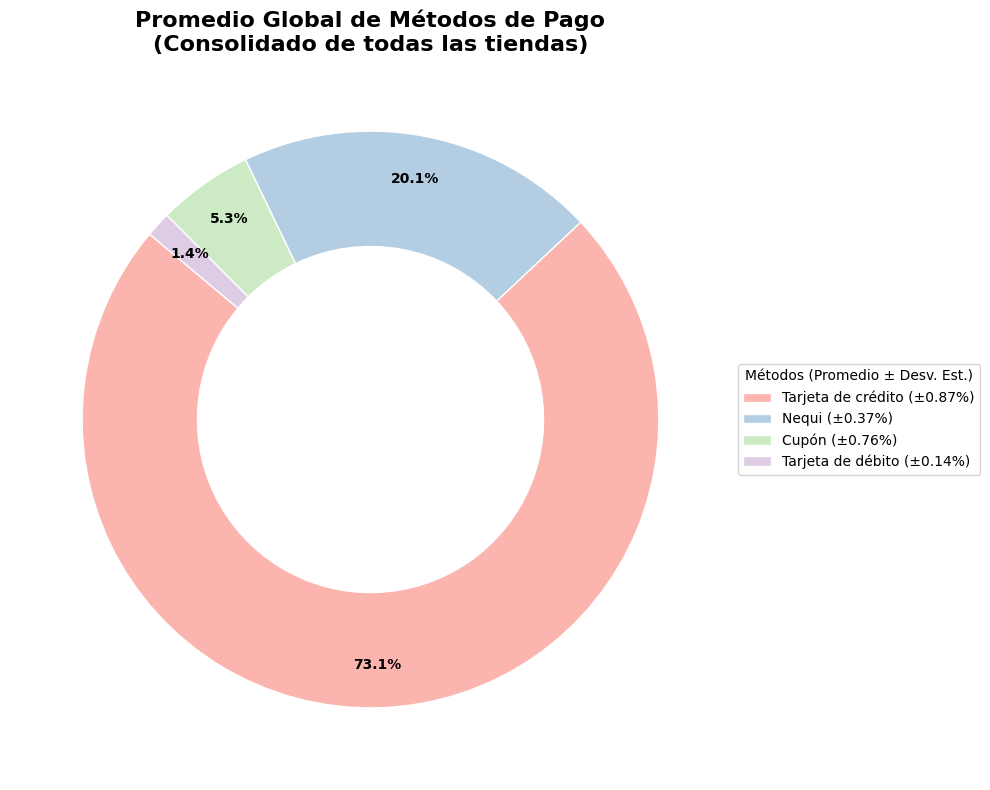

In [23]:
# @title

#Calculamos los porcentajes por tienda
lista_porcentajes = []
for df in lista_tiendas:
    pct = df['Método de pago'].value_counts(normalize=True) * 100
    lista_porcentajes.append(pct)

#Unimos los datos y calculamos Promedio y Desviación Estándar
df_comparativo = pd.concat(lista_porcentajes, axis=1)
promedios = df_comparativo.mean(axis=1)
desviaciones = df_comparativo.std(axis=1)

#Preparamos los datos para el gráfico
labels = promedios.index
sizes = promedios.values

# Configuración del gráfico de anillo
fig, ax = plt.subplots(figsize=(10, 8))
colores = plt.cm.Pastel1.colors

# Crear el gráfico de pastel
wedges, texts, autotexts = ax.pie(
    sizes,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=colores,
    wedgeprops=dict(width=0.4, edgecolor='w') # width=0.4 crea el anillo
)

# Crear etiquetas personalizadas para la leyenda con la Desviación Estándar
legend_labels = [f'{l} (±{d:.2f}%)' for l, d in zip(labels, desviaciones)]

ax.legend(
    wedges,
    legend_labels,
    title="Métodos (Promedio ± Desv. Est.)",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Promedio Global de Métodos de Pago\n(Consolidado de todas las tiendas)', fontsize=16, fontweight='bold')
plt.setp(autotexts, size=10, weight="bold")

plt.tight_layout()
plt.show()

/tmp/ipython-input-358/2860644118.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapa_plot = mapa_base_col.merge(ingresos, on='name', how='left').fillna(0)
/tmp/ipython-input-358/2860644118.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapa_plot = mapa_base_col.merge(ingresos, on='name', how='left').fillna(0)
/tmp/ipython-input-358/2860644118.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future

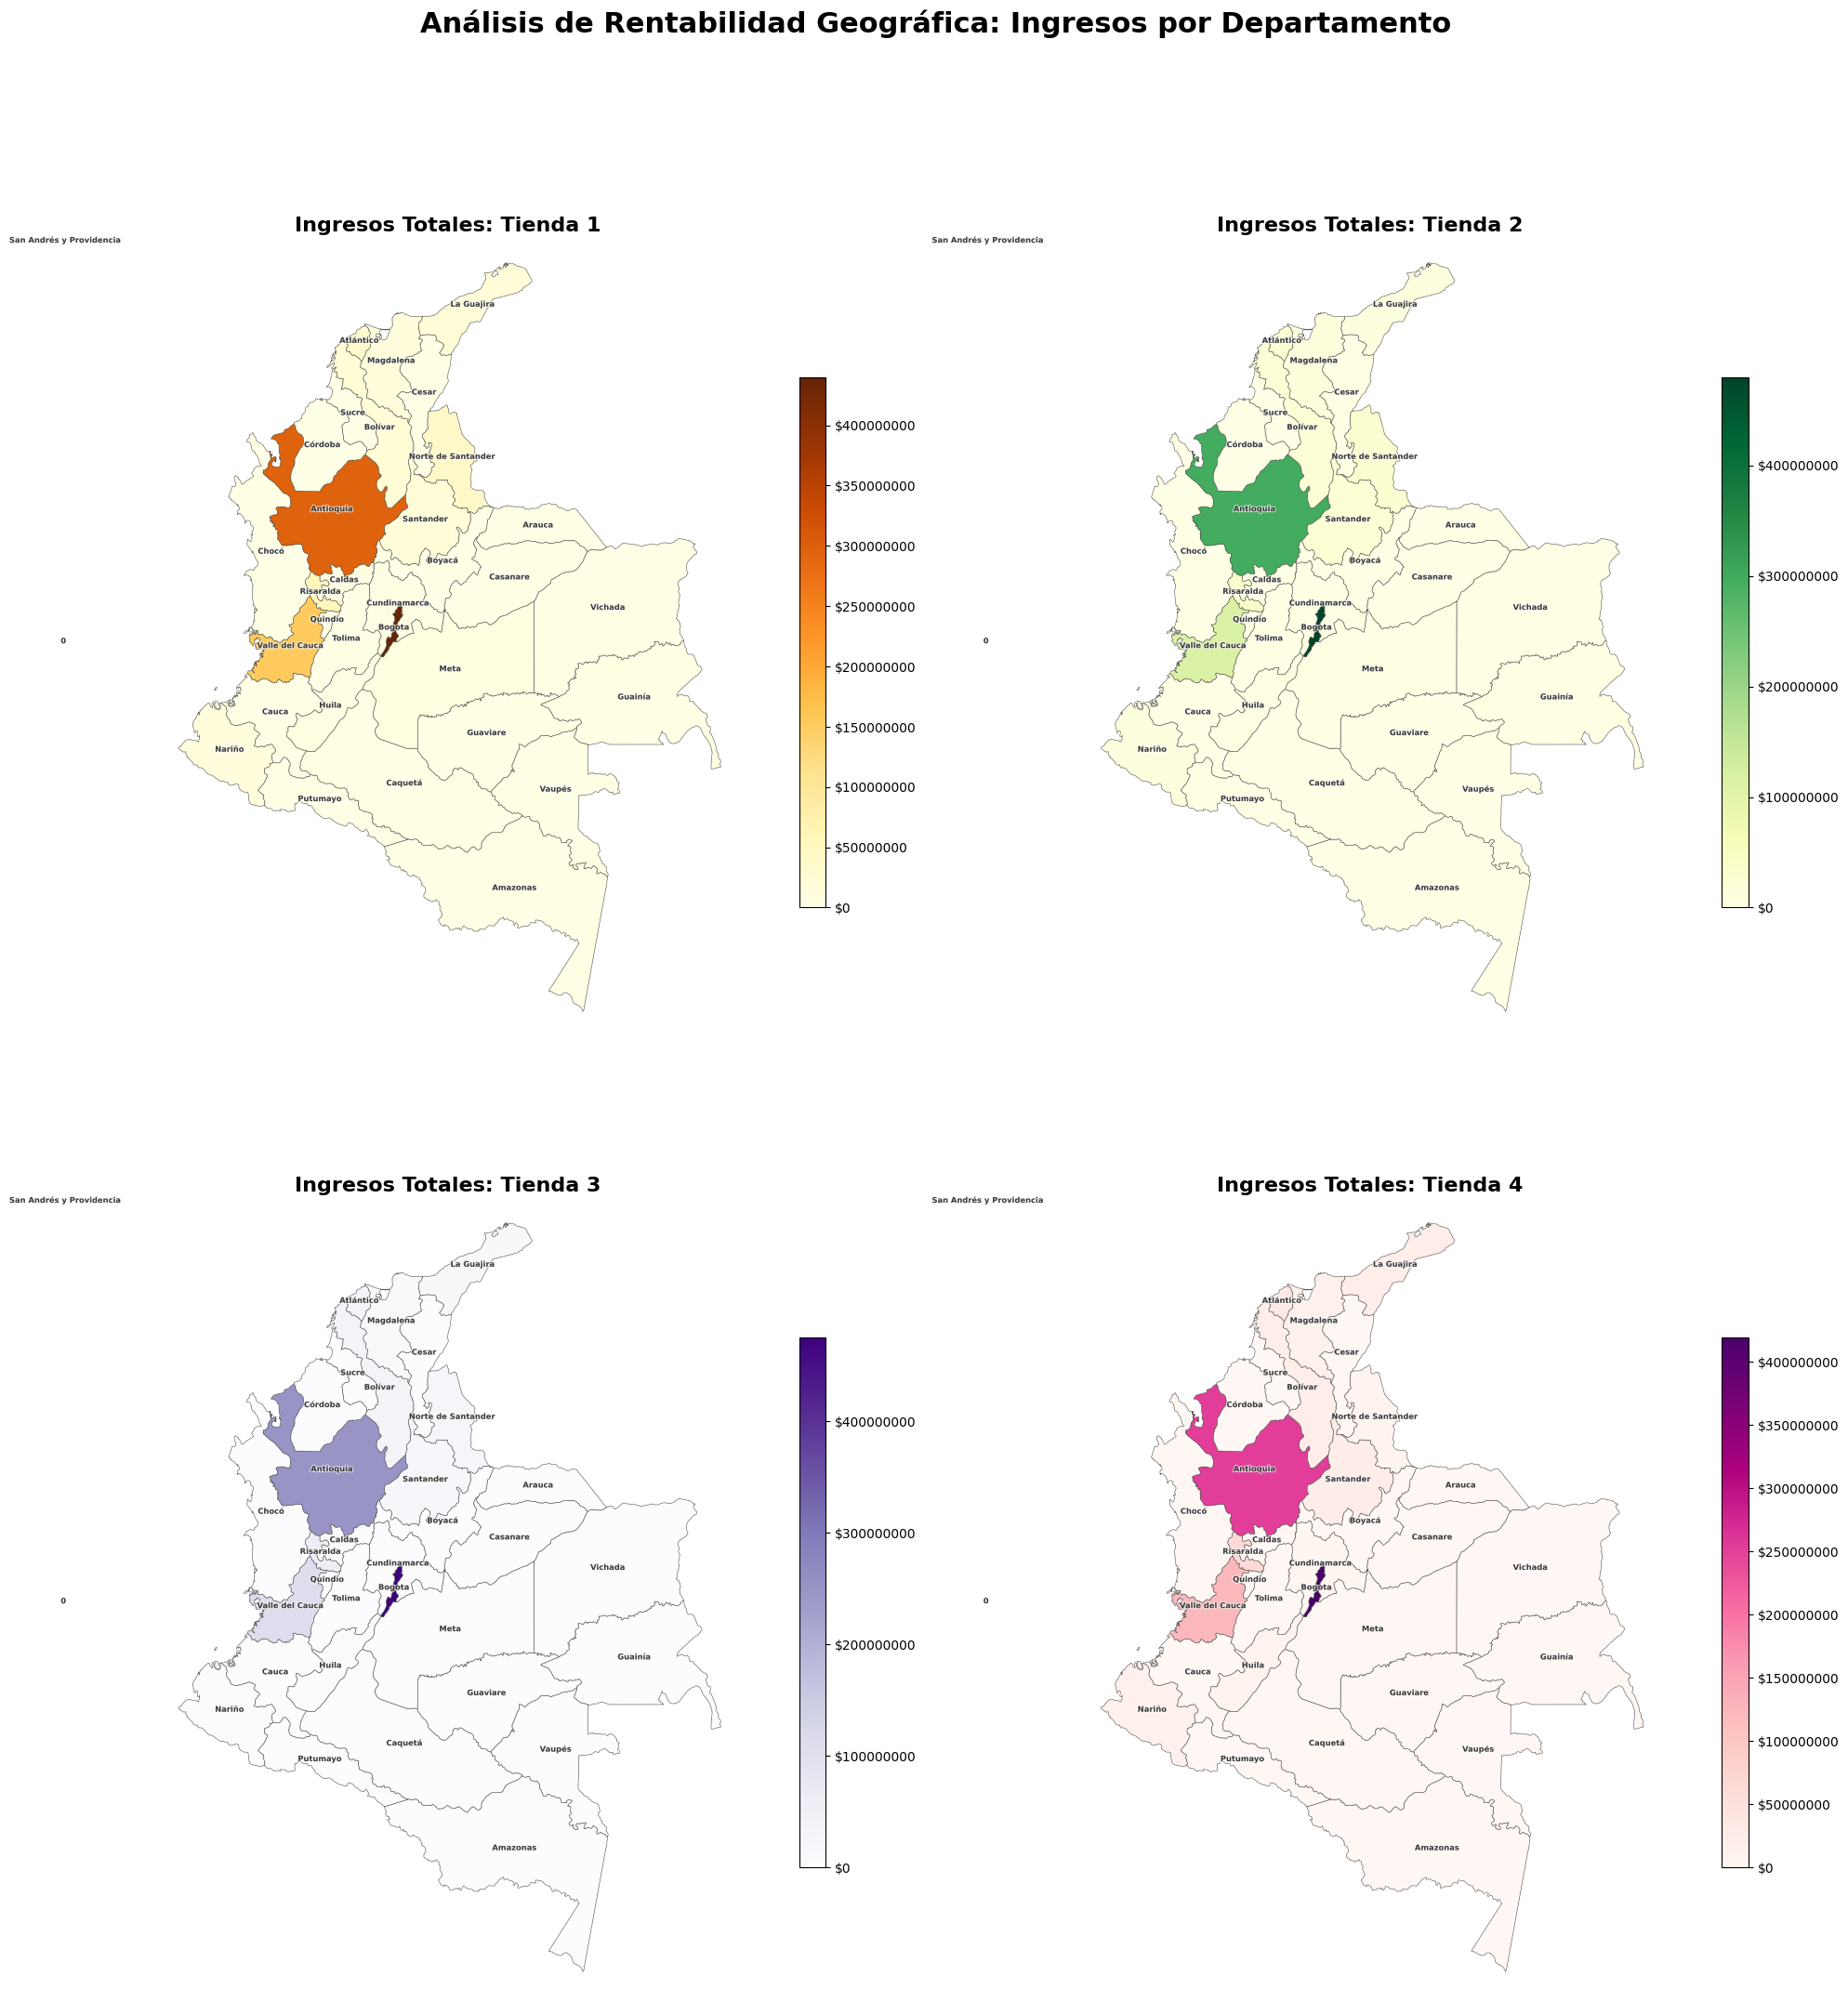

In [24]:
# @title
import geopandas as gpd
from matplotlib import patheffects

# Base del mapa (se mantiene igual)
world_url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson"
world_provinces = gpd.read_file(world_url)
mapa_base_col = world_provinces[world_provinces['admin'] == 'Colombia'].copy()

# Configuración de la figura
fig, axes = plt.subplots(2, 2, figsize=(20, 25))
axes = axes.flatten()

# Usaremos paletas secuenciales "miel/oro" para representar dinero (YlOrBr = Yellow-Orange-Brown)
paletas_dinero = ['YlOrBr', 'YlGn', 'Purples', 'RdPu']

for i, df in enumerate(lista_tiendas):
    ax = axes[i]
    nombre_tienda = nombres_tiendas[i]

    # GeoDataFrame de la tienda
    gdf_tienda = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.lon, df.lat),
        crs="EPSG:4326"
    )

    # Unión Espacial
    mapa_tienda = gpd.sjoin(mapa_base_col, gdf_tienda, how="left", predicate="contains")

    # Sumamos el Precio en lugar de contar filas
    ingresos = mapa_tienda.groupby('name')['Precio'].sum().reset_index(name='Ingresos')

    # Unir ingresos al mapa
    mapa_plot = mapa_base_col.merge(ingresos, on='name', how='left').fillna(0)

    # Graficar Ingresos
    mapa_plot.plot(column='Ingresos',
                  cmap=paletas_dinero[i],
                  linewidth=0.4,
                  ax=ax,
                  edgecolor='0.3',
                  legend=True,
                  legend_kwds={'shrink': 0.5, 'format': '$%.0f'}) # Formato moneda en la leyenda

    # Nombres de departamentos
    for idx, row in mapa_plot.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row['name'],
                fontsize=6, ha='center', fontweight='bold', alpha=0.7,
                path_effects=[patheffects.withStroke(linewidth=1.5, foreground="white")])

    ax.set_title(f'Ingresos Totales: {nombre_tienda}', fontsize=16, fontweight='bold')
    ax.set_xlim([-80, -66])
    ax.set_ylim([-5, 13])
    ax.set_axis_off()

plt.suptitle('Análisis de Rentabilidad Geográfica: Ingresos por Departamento', fontsize=22, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

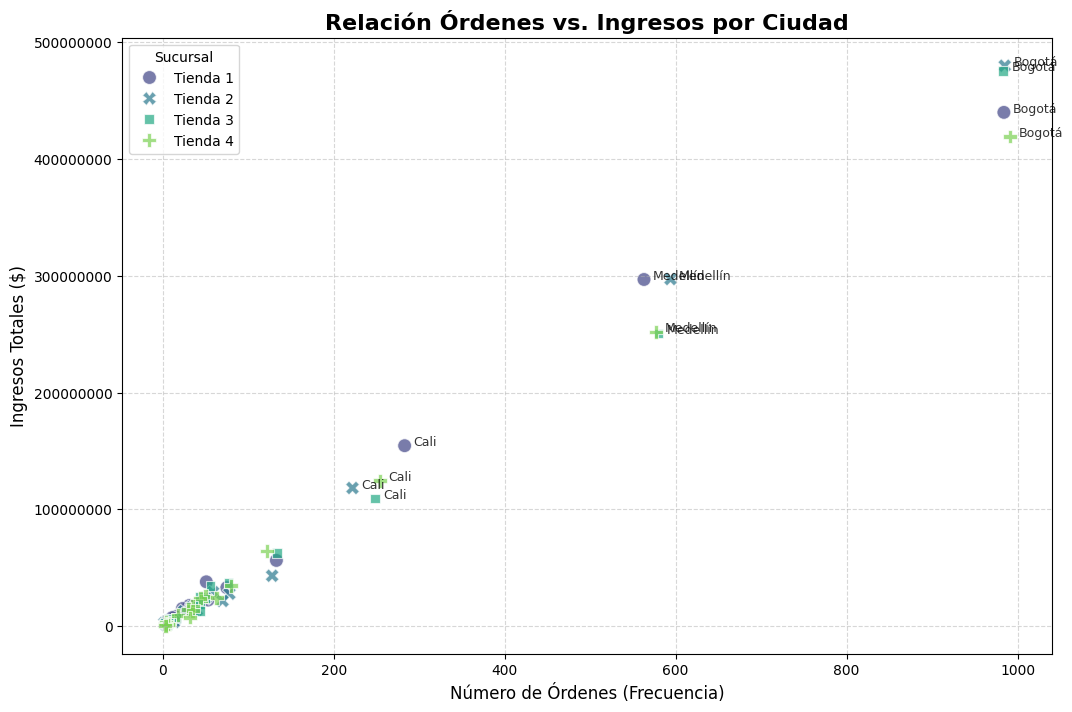

In [25]:
# @title

# Lista para guardar los rankings de cada tienda
rankings_por_tienda = []

for i, df in enumerate(lista_tiendas):
    # Agrupar por Lugar de Compra para la tienda actual
    resumen = df.groupby('Lugar de Compra').agg(
        Ingresos=('Precio', 'sum'),
        Ordenes=('Precio', 'count')
    ).reset_index()

    # Ordenar de mayor a menor ingreso
    resumen = resumen.sort_values(by='Ingresos', ascending=False).reset_index(drop=True)

    # Calcular participación porcentual local (dentro de esta tienda)
    total_tienda = resumen['Ingresos'].sum()
    resumen['Participacion_%'] = (resumen['Ingresos'] / total_tienda * 100).round(2)

    # Guardar en nuestra lista
    rankings_por_tienda.append(resumen)

# Preparar los datos (usamos el DataFrame comparativo que creamos antes)
plt.figure(figsize=(12, 8))

# Unificar los rankings para graficar
# Agregamos una columna de 'Tienda' a cada DataFrame de tu lista
for i, df in enumerate(rankings_por_tienda):
    df['Tienda'] = nombres_tiendas[i]

df_comparativo = pd.concat(rankings_por_tienda)

# Crear el scatter plot
# El tamaño del punto (s) representará la participación porcentual
sns.scatterplot(
    data=df_comparativo,
    x='Ordenes',
    y='Ingresos',
    hue='Tienda',
    style='Tienda',
    s=100,
    alpha=0.7,
    palette='viridis'
)

# Etiquetar las ciudades más importantes para dar contexto
# Solo etiquetamos las que tienen más de 200 órdenes para no amontonar texto
for i in range(df_comparativo.shape[0]):
    row = df_comparativo.iloc[i]
    if row['Ordenes'] > 200:
        plt.text(
            row['Ordenes']+10,
            row['Ingresos'],
            row['Lugar de Compra'],
            fontsize=9,
            alpha=0.8
        )

# Estética
plt.title('Relación Órdenes vs. Ingresos por Ciudad', fontsize=16, fontweight='bold')
plt.xlabel('Número de Órdenes (Frecuencia)', fontsize=12)
plt.ylabel('Ingresos Totales ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Quitar notación científica
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Sucursal')

plt.show()

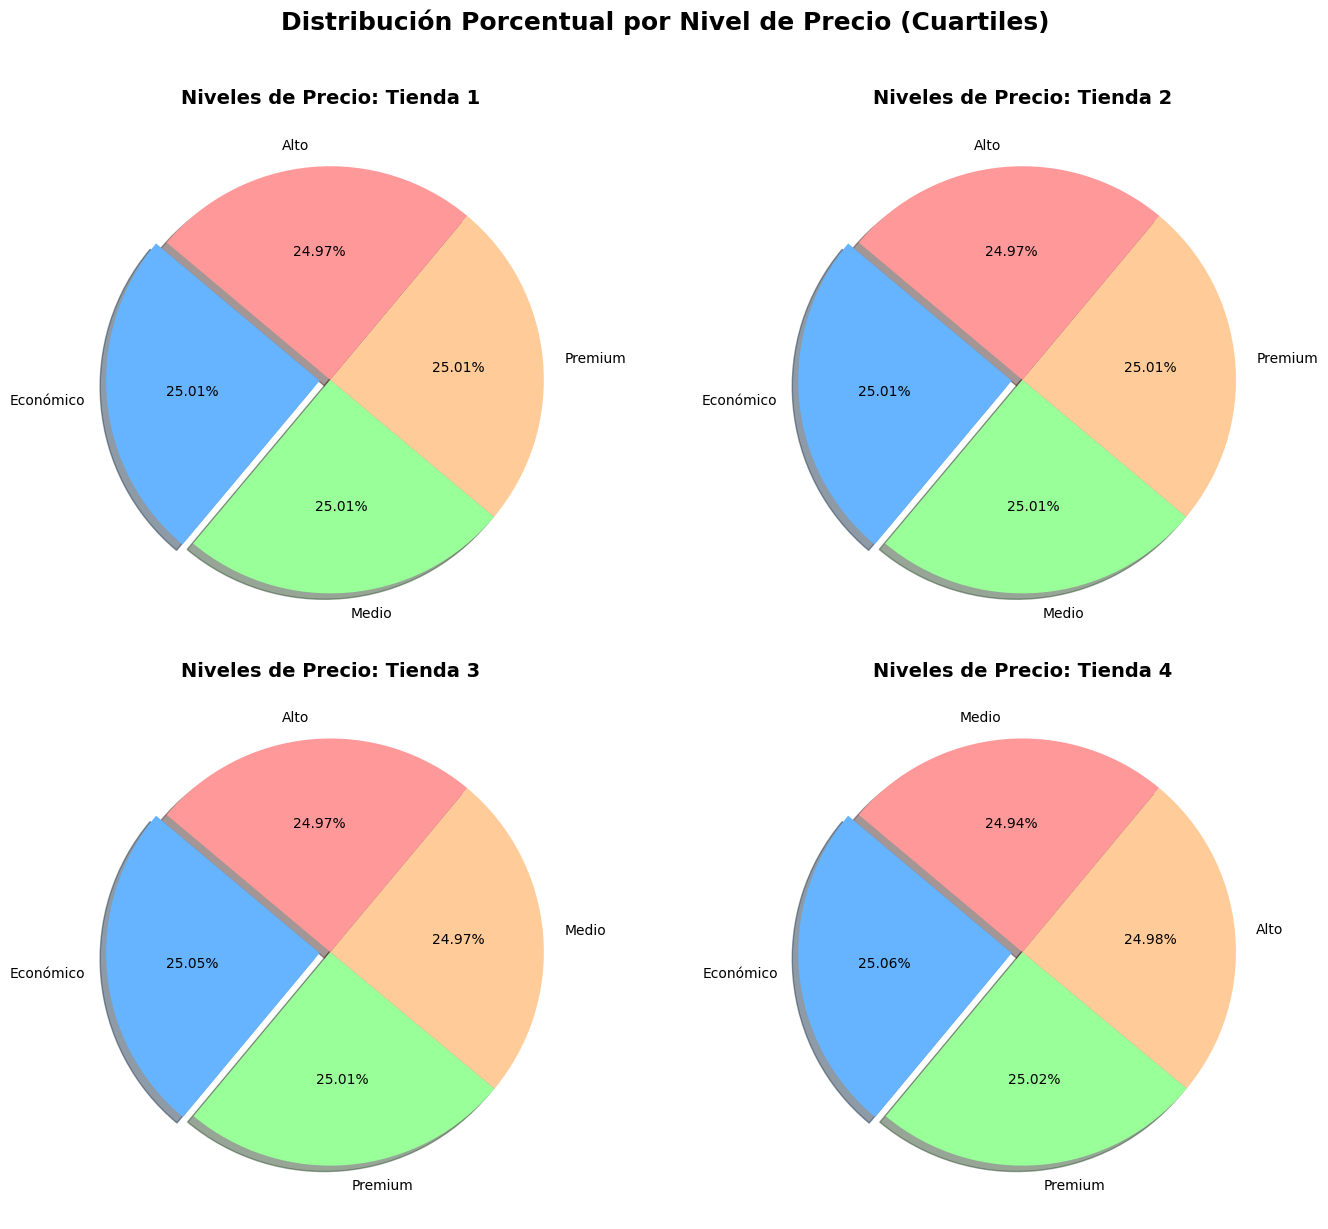

In [26]:
# @title

def analizar_cuartiles(df, nombre):
    # Dividimos los precios de la tienda en 4 grupos iguales (Cuartiles)
    cuartiles = pd.qcut(df['Precio'], 4, labels=['Económico', 'Medio', 'Alto', 'Premium'])
    resumen = cuartiles.value_counts(normalize=True) * 100
    return resumen

# Configuración de la figura 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()

# Colores sugeridos para los niveles de precio
colores = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'] # Económico, Medio, Alto, Premium

resultados_totales = []

for i, df in enumerate(lista_tiendas):
    # Usamos tu función analizar_cuartiles
    resumen = analizar_cuartiles(df, nombres_tiendas[i])
    resultados_totales.append(resumen)

    # Configuración del subplot actual
    ax = axes[i]

    # Crear gráfico de pastel
    ax.pie(
        resumen,
        labels=resumen.index,
        autopct='%1.2f%%',
        startangle=140,
        colors=colores,
        explode=(0.05, 0, 0, 0), # Resalta el sector 'Económico'
        shadow=True
    )

    ax.set_title(f'Niveles de Precio: {nombres_tiendas[i]}', fontsize=14, fontweight='bold')

# Título general
plt.suptitle('Distribución Porcentual por Nivel de Precio (Cuartiles)', fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [27]:
# @title
df_stats = pd.DataFrame(resultados_totales)
print("\nANÁLISIS DE CONSISTENCIA GLOBAL")
media_por_nivel = df_stats.mean()
desv_por_nivel = df_stats.std()

resumen_final = pd.DataFrame({
    'Media %': media_por_nivel,
    'Desviación Est.': desv_por_nivel
})

print(resumen_final.round(2))


ANÁLISIS DE CONSISTENCIA GLOBAL
           Media %  Desviación Est.
Precio                             
Económico    25.03             0.03
Medio        24.98             0.04
Premium      25.01             0.01
Alto         24.97             0.01


In [28]:
# @title
from scipy import stats

for df in lista_tiendas:
      df['Ingreso_Neto'] = df['Precio'] - df['Costo de envío']

# Configuración de estilo y colores neón
plt.style.use('default')
colores_impacto = ['#00FFFF', '#FF00FF', '#00FF00', '#FF4500']

print("ANÁLISIS CIENTÍFICO DE DISTRIBUCIONES\n")

# Confirmación del tipo de distribución (usando el método Shapiro-Wilk)
for i, df in enumerate(lista_tiendas):
    precios = df['Ingreso_Neto'].dropna()
    stat, p_shapiro = stats.shapiro(precios)

    # Determinamos el nombre de la distribución basándonos en la prueba y la forma
    tipo_dist = 'Distribución Normal' if p_shapiro > 0.05 else 'Distribución Log-Normal'

    print(f"[{nombres_tiendas[i]}]")
    print(f"   Prueba Shapiro-Wilk: p-value = {p_shapiro:.4e}")
    print(f"   Tipo de Distribución: {tipo_dist}")
    print("-" * 45)

# Prueba de diferencia fundamental (K-S de 2 muestras)
# Comparamos Tienda 1 (Líder) vs Tienda 4 (Bajo Costo)
t1 = lista_tiendas[0]['Ingreso_Neto']
t4 = lista_tiendas[3]['Ingreso_Neto']
ks_stat, p_ks = stats.ks_2samp(t1, t4)

print(f"\nCOMPARACIÓN CIENTÍFICA (Tienda 1 vs Tienda 4):")
print(f"   Estadístico K-S: {ks_stat:.4f}")
print(f"   Valor p: {p_ks:.4e}")
if p_ks < 0.05:
    print("   CONCLUSIÓN: Existe una diferencia SIGNIFICATIVA en el comportamiento de precios.")
else:
    print("   CONCLUSIÓN: No hay diferencia estadística suficiente entre ambas.")

ANÁLISIS CIENTÍFICO DE DISTRIBUCIONES

[Tienda 1]
   Prueba Shapiro-Wilk: p-value = 1.3640e-50
   Tipo de Distribución: Distribución Log-Normal
---------------------------------------------
[Tienda 2]
   Prueba Shapiro-Wilk: p-value = 2.4765e-50
   Tipo de Distribución: Distribución Log-Normal
---------------------------------------------
[Tienda 3]
   Prueba Shapiro-Wilk: p-value = 2.5099e-50
   Tipo de Distribución: Distribución Log-Normal
---------------------------------------------
[Tienda 4]
   Prueba Shapiro-Wilk: p-value = 1.8176e-51
   Tipo de Distribución: Distribución Log-Normal
---------------------------------------------

COMPARACIÓN CIENTÍFICA (Tienda 1 vs Tienda 4):
   Estadístico K-S: 0.0482
   Valor p: 7.8782e-03
   CONCLUSIÓN: Existe una diferencia SIGNIFICATIVA en el comportamiento de precios.


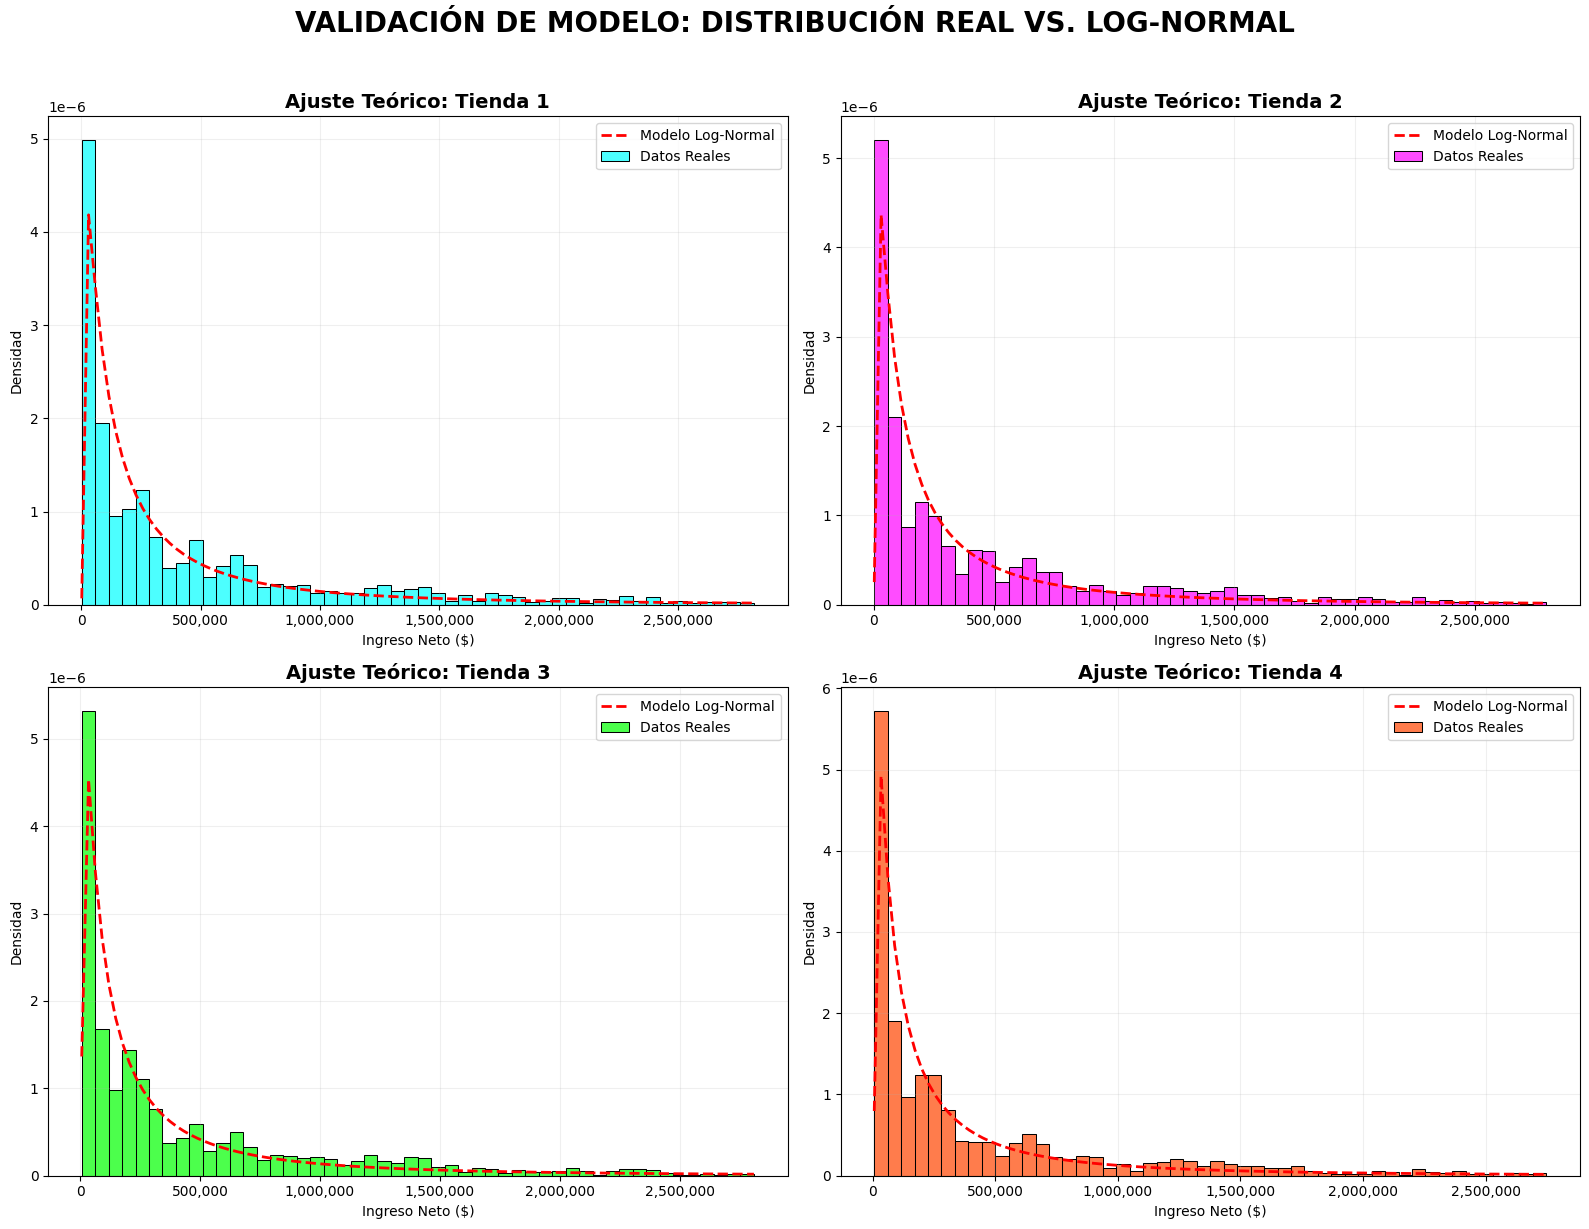

In [29]:
# @title
# Visualización: datos reales comparados con el modelo teórico (log-normal)
# Usamos Log-Normal porque en retail los precios suelen seguir esta curva (mucha masa al inicio, cola larga)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, df in enumerate(lista_tiendas):
    precios = df['Ingreso_Neto'].dropna()
    ax = axes[i]

    # Graficar histograma real
    sns.histplot(precios, bins=50, kde=False, stat="density", color=colores_impacto[i], alpha=0.7, ax=ax, label="Datos Reales")

    # Ajustar una distribución Log-Normal teórica a los datos
    shape, loc, scale = stats.lognorm.fit(precios)
    x = np.linspace(precios.min(), precios.max(), 100)
    pdf_teorica = stats.lognorm.pdf(x, shape, loc, scale)

    # Graficar curva teórica
    ax.plot(x, pdf_teorica, 'r--', linewidth=2, label='Modelo Log-Normal')

    # Formato
    ax.set_title(f'Ajuste Teórico: {nombres_tiendas[i]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ingreso Neto ($)')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.suptitle('VALIDACIÓN DE MODELO: DISTRIBUCIÓN REAL VS. LOG-NORMAL', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

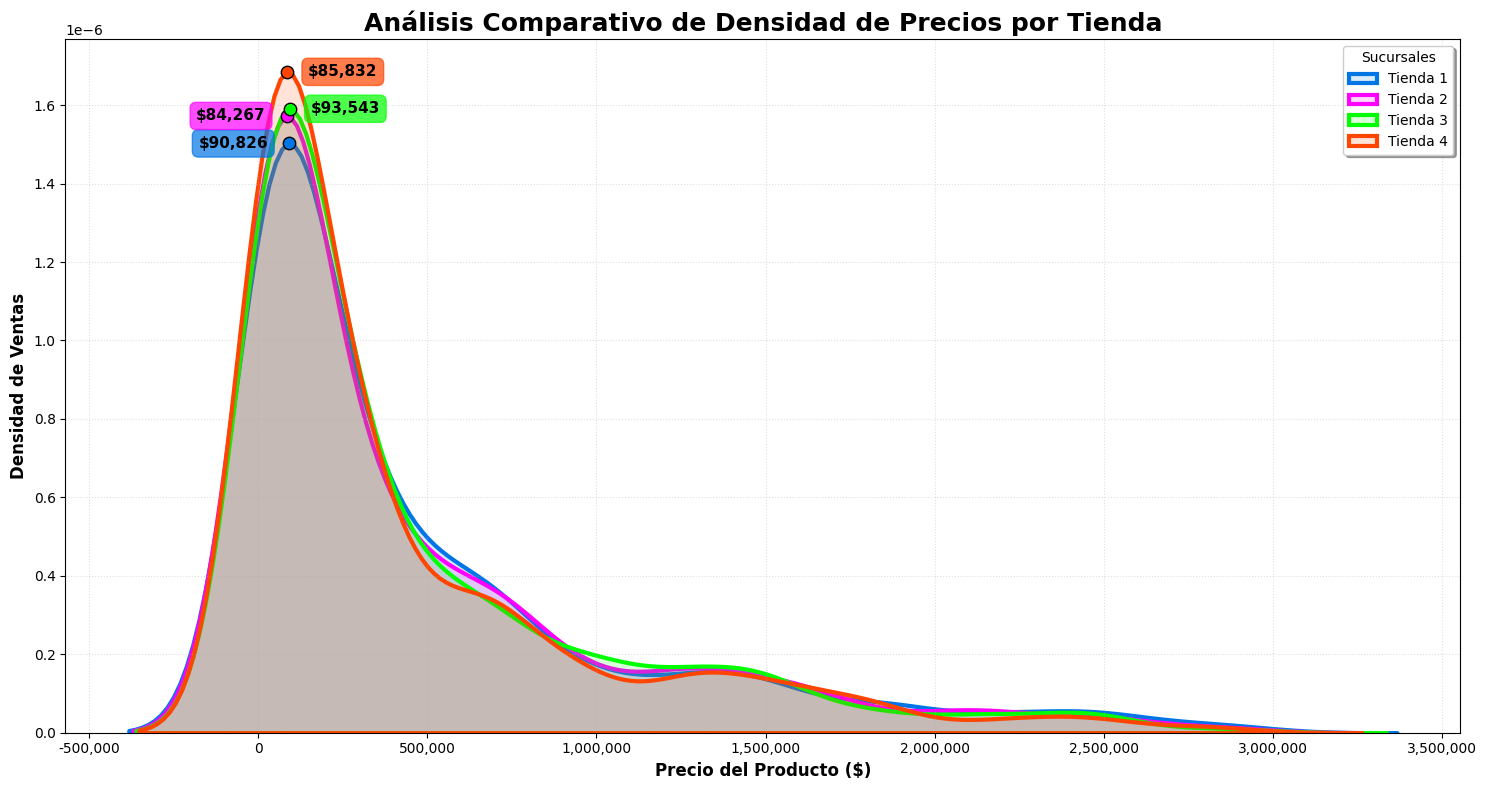

In [30]:
# @title
from scipy.stats import gaussian_kde

plt.figure(figsize=(15, 8))

# Colores (Cian, Magenta, Lima, Naranja Eléctrico)
colores_impacto = ['#0076E6', '#FF00FF', '#00FF00', '#FF4500']

for i, df in enumerate(lista_tiendas):
    datos = df['Precio'].dropna()

    # Graficar el KDE
    sns.kdeplot(data=datos, label=nombres_tiendas[i], fill=True,
                color=colores_impacto[i], alpha=0.15, linewidth=3)

    # Cálculo del pico
    kde = gaussian_kde(datos)
    x_range = np.linspace(datos.min(), datos.max(), 1000)
    y_values = kde(x_range)

    idx_pico = np.argmax(y_values)
    pico_x = x_range[idx_pico]
    pico_y = y_values[idx_pico]

    # Punto del pico
    plt.scatter(pico_x, pico_y, color=colores_impacto[i], s=80, zorder=10, edgecolors='black')

    # Lógica de dirección: Tiendas 0 y 1 a la izquierda, 2 y 3 a la derecha
    if i < 2:
        direccion_x = -15
        alineacion = 'right'
    else:
        direccion_x = 15
        alineacion = 'left'

    # Etiqueta con el cuadro del color de la tienda y texto negro
    plt.annotate(f'${pico_x:,.0f}',
                 xy=(pico_x, pico_y),
                 xytext=(direccion_x, 0),    # Dinámico según la tienda
                 textcoords='offset points',
                 fontsize=11,
                 fontweight='bold',
                 color='black',              # Texto siempre negro
                 ha=alineacion,              # Dinámico según la tienda
                 va='center',
                 bbox=dict(boxstyle='round,pad=0.4',
                           fc=colores_impacto[i],
                           ec=colores_impacto[i],
                           alpha=0.7))

# Estética final
plt.title('Análisis Comparativo de Densidad de Precios por Tienda', fontsize=18, fontweight='bold')
plt.xlabel('Precio del Producto ($)', fontsize=12, fontweight='bold')
plt.ylabel('Densidad de Ventas', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(title="Sucursales", frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# 2. Ventas por categoría

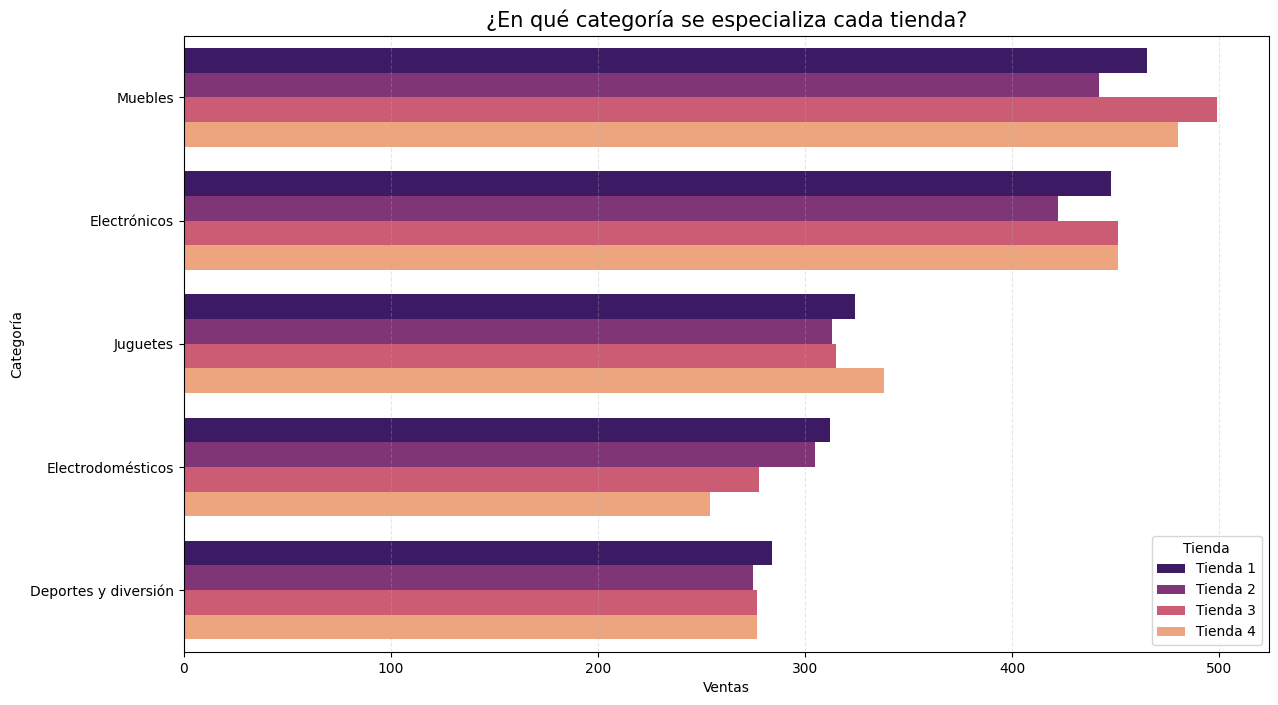

In [31]:
# @title

# Se seleccionan las mayores categorías en todo el conunto de tiendas
conteo_total = pd.Series(dtype=int)
for df in lista_tiendas:
    conteo_total = conteo_total.add(df['Categoría del Producto'].value_counts(), fill_value=0)

top_global = conteo_total.nlargest(5).index

# Se prepara una lista de datos para agrupar los datos de las 5 mayores categorías
datos_para_grafico = []
for i, df in enumerate(lista_tiendas):
    conteo_tienda = df['Categoría del Producto'].value_counts()
    for cat in top_global:
        # Extraemos el valor de cada categoría para cada tienda
        valor = conteo_tienda.get(cat, 0)
        datos_para_grafico.append({'Tienda': nombres_tiendas[i], 'Categoría': cat, 'Ventas': valor})

# Convertir solo lo necesario para Seaborn
df_plot = pd.DataFrame(datos_para_grafico)

# Gráfico
plt.figure(figsize=(14, 8))
sns.barplot(x='Ventas', y='Categoría', hue='Tienda', data=df_plot, palette='magma')

plt.title('¿En qué categoría se especializa cada tienda?', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# 3. Calificación promedio de la tienda


In [32]:
# @title
print("3. CALIFICACIÓN PROMEDIO DE LA TIENDA")
valoraciones = [df['Calificación'].mean() for df in lista_tiendas]
tabla_valoracion = pd.DataFrame({'Tienda': nombres_tiendas, 'Valoración Media': valoraciones})
tabla_valoracion['Valoración Media'] = tabla_valoracion['Valoración Media'].map('{:.2f}'.format)
display(tabla_valoracion)

3. CALIFICACIÓN PROMEDIO DE LA TIENDA


,Tienda,Valoración Media
0,Tienda 1,3.98
1,Tienda 2,4.04
2,Tienda 3,4.05
3,Tienda 4,4.00


# 4. Productos más y menos vendidos

In [33]:
# @title

# Configuración de la cuadrícula de 2x2 para colab
grid_productos = widgets.GridspecLayout(2, 2)

for i, df in enumerate(lista_tiendas):
    # Se agrupan por producto y así obtener los datos de ventas
    resumen_p = df.groupby('Producto').agg(
        Cantidad_Vendida=('Producto', 'count'),
        Precio_Unitario=('Precio', 'mean'),
        Ventas_Totales=('Precio', 'sum')
    ).reset_index()

    # Redondeo a 2 cifras después del punto
    resumen_p['Precio_Unitario'] = resumen_p['Precio_Unitario'].round(2)
    resumen_p['Ventas_Totales'] = resumen_p['Ventas_Totales'].round(2)

    # Ordenamos por cantidad para extraer Top 5 y Bottom 5
    resumen_p = resumen_p.sort_values(by='Cantidad_Vendida', ascending=False)
    top_bottom = pd.concat([resumen_p.head(5), resumen_p.tail(5)]).reset_index(drop=True)

    out = widgets.Output()
    with out:
        print(f" {nombres_tiendas[i]} ")
        display(top_bottom)

    # Asignación a la cuadrícula (fila, columna)
    grid_productos[i // 2, i % 2] = out

# Visualización
print("4. PRODUCTOS MÁS Y MENOS VENDIDOS (Análisis de Ventas Totales y Precio Unitario)")
display(grid_productos)

4. PRODUCTOS MÁS Y MENOS VENDIDOS (Análisis de Ventas Totales y Precio Unitario)


GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

# 5. Envío promedio por tienda

In [34]:
# @title
print("5. ENVÍO PROMEDIO POR TIENDA")
envios = [df['Costo de envío'].mean() for df in lista_tiendas]
tabla_envios = pd.DataFrame({'Tienda': nombres_tiendas, 'Envío Promedio': envios})
display(tabla_envios)

5. ENVÍO PROMEDIO POR TIENDA


,Tienda,Envío Promedio
0,Tienda 1,26018.609580
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167


# Informe Final de Análisis para la Toma de Decisión

## Determinación de la tienda a vender

### Introducción

El presente informe tiene como finalidad identificar la tienda con menor desempeño relativo para recomendar su venta, a partir de un análisis cuantitativo y estadístico de los datos comerciales disponibles. La evaluación se realizó considerando métricas agregadas de ingresos, volumen de operaciones, distribución de ventas por categoría, calificaciones promedio de clientes, costos de envío, comportamiento temporal de las ventas y análisis estadístico de las distribuciones de ingresos.

La metodología empleada integra análisis descriptivo, comparativo y probabilístico, con apoyo en visualizaciones y pruebas estadísticas, permitiendo una toma de decisión fundamentada y objetiva.

### Análisis de ingresos y volumen de operaciones

El análisis de la facturación neta total evidencia una diferencia estructural entre las tiendas. La Tienda 4 presenta el menor ingreso acumulado, con aproximadamente 983 millones, mientras que las Tiendas 1, 2 y 3 superan los 1,000 millones.

Este resultado es particularmente relevante al observar que el volumen total de órdenes es prácticamente idéntico entre las tiendas (≈2,359 operaciones). Por lo tanto, la diferencia en ingresos no se explica por la cantidad de ventas, sino por el valor económico promedio de las transacciones, el cual es sistemáticamente menor en la Tienda 4.

### Comportamiento temporal de ventas e ingresos

El análisis de series temporales de ventas mensuales e ingresos netos muestra patrones similares entre las cuatro tiendas, con fluctuaciones periódicas y ausencia de estacionalidades atípicas. Sin embargo, la Tienda 4 presenta menores amplitudes en los picos de ingresos, incluso durante periodos de alta actividad comercial.

Este comportamiento sugiere una limitación estructural en la capacidad de la Tienda 4 para capturar ventas de alto valor, más que un problema coyuntural o temporal.

### Distribución de ventas por categoría de producto

La estructura de ventas por categoría es altamente homogénea entre las tiendas. En todos los casos, la categoría de muebles concentra la mayor cantidad de ventas, seguida por electrónicos, juguetes, electrodomésticos y deportes y diversión.

Dado que la composición porcentual por categoría es prácticamente equivalente, se descarta que la especialización de productos sea un factor determinante en la diferencia de ingresos. No obstante, se observa que la Tienda 4 presenta una menor participación en electrodomésticos, una categoría asociada a tickets promedio más elevados.

### Calificaciones promedio de clientes

El análisis de las calificaciones promedio revela una desconexión entre percepción del cliente e ingresos generados. La Tienda 1, a pesar de tener la calificación promedio más baja, es la que registra mayores ingresos, mientras que la Tienda 4, con una calificación superior, es la que menos factura.

Esto indica que, en este conjunto de datos, la calificación no actúa como un predictor significativo del desempeño económico.

### Productos más y menos vendidos

El patrón de los productos con mayor y menor volumen de ventas es consistente con la distribución por categorías y no presenta diferencias sustanciales entre tiendas. No se identifican productos específicos cuya ausencia o baja rotación explique el menor rendimiento de la Tienda 4, reforzando la hipótesis de una limitación global en el valor de las transacciones.

### Coste de envío promedio

El costo de envío promedio muestra una relación positiva con el nivel de ingresos totales. La Tienda 4 presenta el menor coste de envío promedio, con una diferencia cercana a los 1,000 pesos respecto a la tienda con mayor facturación.

Este comportamiento es coherente con una menor magnitud de pedidos y confirma indirectamente la existencia de tickets promedio más bajos en la Tienda 4.

### Análisis estadístico de la distribución de ingresos

Las pruebas de normalidad (Shapiro-Wilk) indican que los ingresos netos de todas las tiendas siguen una distribución log-normal, característica típica de variables económicas.

La comparación directa entre la Tienda 1 y la Tienda 4 mediante la prueba de Kolmogórov-Smirnov arroja una diferencia estadísticamente significativa, evidenciando que ambas tiendas no comparten el mismo comportamiento distributivo en términos de ingresos.

El análisis de colas de la distribución revela que la Tienda 4 presenta una mayor concentración de densidad en rangos bajos de ingreso (0–500,000 pesos) y un umbral inferior para ingresos extremos. Adicionalmente, la moda de la distribución de la Tienda 4 es considerablemente menor y presenta mayor densidad, lo que indica una alta frecuencia de transacciones de bajo valor.

Este patrón sugiere que el desempeño inferior de la Tienda 4 no es aleatorio, sino estructural y persistente.

### Conclusión y recomendación

Integrando los resultados del análisis descriptivo, temporal, categórico y estadístico, se concluye que la Tienda 4 presenta el desempeño económico más débil entre las evaluadas. A pesar de operar bajo condiciones similares a las demás tiendas (volumen de ventas, distribución geográfica, métodos de pago y estructura de precios), muestra una concentración significativa de ingresos bajos y una menor capacidad para generar ventas de alto valor.

En consecuencia, desde una perspectiva técnica, cuantitativa y estadísticamente respaldada, se recomienda al Sr. Juan proceder con la venta de la Tienda 4, al ser la alternativa con menor rentabilidad relativa y menor potencial de mejora estructural.